In [3]:
import pandas as pd
import bt as bt
import yfinance as yf
import matplotlib
import datetime as dt
import numpy as np
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
from scipy.optimize import minimize
%matplotlib inline

In [4]:
inicio = dt.date(2015, 1, 1)
final = dt.date(2024, 10, 31)

In [5]:
financeiro_teste = 1000000

carteira_25 = ["AGRO3", "CSAN3", "UNIP6", "BRKM5", "CMIG4", "BBAS3", "KLBN11", "VALE3"]

#np.setdiff1d(carteira_25, carteira_25_v2) -> verificar a diferença entre as carteiras 1 e 2

In [6]:
carteira = carteira_25
carteira = [acao + ".SA" for acao in carteira]

In [7]:
precos = yf.download(carteira, inicio, final)['Adj Close']
precos.dropna(inplace=True)
precos

[*********************100%***********************]  8 of 8 completed


Ticker,AGRO3.SA,BBAS3.SA,BRKM5.SA,CMIG4.SA,CSAN3.SA,KLBN11.SA,UNIP6.SA,VALE3.SA
Date,,,,,,,,
2015-01-02 00:00:00+00:00,4.035699,6.155694,11.003018,2.558451,5.104055,8.753355,1.003288,11.635607
2015-01-05 00:00:00+00:00,4.059027,6.027956,10.339425,2.492491,4.801115,8.538960,0.960594,11.460636
2015-01-06 00:00:00+00:00,4.124345,6.112209,10.118226,2.470504,4.612011,8.820736,0.981941,11.919934
2015-01-07 00:00:00+00:00,4.124345,6.381265,10.111906,2.470504,4.679941,8.912619,0.981941,12.357368
2015-01-08 00:00:00+00:00,4.059027,6.403008,10.137188,2.450516,4.736856,8.906491,0.981941,12.488592
...,...,...,...,...,...,...,...,...
2024-10-24 00:00:00+00:00,23.420000,26.360001,17.400000,11.220000,11.820000,20.430000,45.279999,59.700001
2024-10-25 00:00:00+00:00,23.530001,26.370001,17.330000,11.150000,11.750000,20.840000,46.020000,61.730000
2024-10-28 00:00:00+00:00,23.620001,26.320000,17.940001,11.290000,12.070000,20.700001,45.500000,62.880001


In [8]:
retornos = precos.pct_change().apply(lambda x: np.log(1+x)).dropna()
media_retornos = retornos.mean()
matriz_cov = retornos.cov() 
media_retornos

Ticker
AGRO3.SA     0.000724
BBAS3.SA     0.000595
BRKM5.SA     0.000194
CMIG4.SA     0.000610
CSAN3.SA     0.000350
KLBN11.SA    0.000354
UNIP6.SA     0.001556
VALE3.SA     0.000687
dtype: float64

In [9]:
numero_carteiras = 100000
tabela_retornos_esperados = np.zeros(numero_carteiras)
tabela_volatilidades_esperadas = np.zeros(numero_carteiras)
tabela_sharpe = np.zeros(numero_carteiras)
tabela_pesos = np.zeros((numero_carteiras, len(carteira)))

for k in range(numero_carteiras):
    
    pesos = np.random.random(len(carteira))
    pesos = pesos/np.sum(pesos)
    tabela_pesos[k, :] = pesos
    
    tabela_retornos_esperados[k] = np.sum(media_retornos * pesos * 252)
    tabela_volatilidades_esperadas[k] = np.sqrt(np.dot(pesos.T, np.dot(matriz_cov*252, pesos)))
    
    tabela_sharpe[k] = tabela_retornos_esperados[k]/tabela_volatilidades_esperadas[k]

In [10]:
indice_do_sharpe_maximo = tabela_sharpe.argmax()
tabela_pesos[indice_do_sharpe_maximo]

array([0.32072308, 0.09180497, 0.01339072, 0.02908976, 0.00135005,
       0.10837713, 0.34467353, 0.09059076])

In [11]:
carteira

['AGRO3.SA',
 'CSAN3.SA',
 'UNIP6.SA',
 'BRKM5.SA',
 'CMIG4.SA',
 'BBAS3.SA',
 'KLBN11.SA',
 'VALE3.SA']

In [12]:
df = pd.DataFrame(carteira, columns=['Stock'])
df['Weight'] = pd.DataFrame(tabela_pesos[indice_do_sharpe_maximo])

df

,Stock,Weight
0,AGRO3.SA,0.320723
1,CSAN3.SA,0.091805
2,UNIP6.SA,0.013391
3,BRKM5.SA,0.029090
4,CMIG4.SA,0.001350
5,BBAS3.SA,0.108377
6,KLBN11.SA,0.344674
7,VALE3.SA,0.090591


In [13]:
tabela_retornos_esperados_arit = np.exp(tabela_retornos_esperados) - 1

In [14]:
eixo_y_fronteira_eficiente = np.linspace(tabela_retornos_esperados_arit.min(), 
                                         tabela_retornos_esperados_arit.max(), 50)

def pegando_retorno(peso_teste):
    peso_teste = np.array(peso_teste)
    retorno = np.sum(media_retornos * peso_teste) * 252
    retorno = np.exp(retorno) - 1

    return retorno

def checando_soma_pesos(peso_teste):

    return np.sum(peso_teste)-1

def pegando_vol(peso_teste):
    peso_teste = np.array(peso_teste)
    vol = np.sqrt(np.dot(peso_teste.T, np.dot(matriz_cov*252, peso_teste)))
    
    return vol

peso_inicial = [1/len(carteira)] * len(carteira) 
limites = tuple([(0, 1) for ativo in carteira])

eixo_x_fronteira_eficiente = []

for retorno_possivel in eixo_y_fronteira_eficiente:
    
    restricoes = ({'type':'eq', 'fun':checando_soma_pesos},
            {'type':'eq', 'fun': lambda w: pegando_retorno(w) - retorno_possivel})
    
    result = minimize(pegando_vol,peso_inicial,method='SLSQP', bounds=limites, 
                      constraints=restricoes)
    eixo_x_fronteira_eficiente.append(result['fun'])

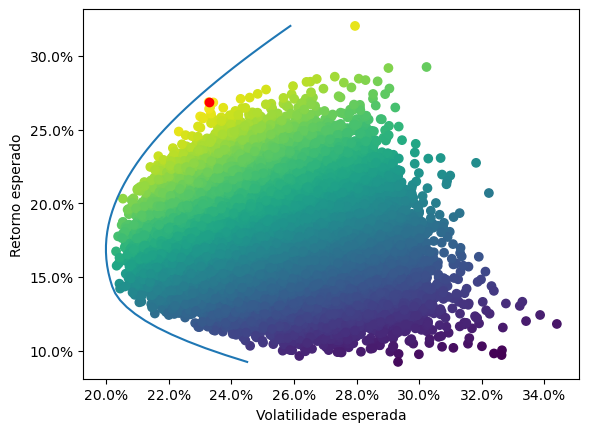

In [19]:
fig, ax = plt.subplots()

ax.scatter(tabela_volatilidades_esperadas, tabela_retornos_esperados_arit, c = tabela_sharpe)
plt.xlabel("Volatilidade esperada")
plt.ylabel("Retorno esperado")
ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')
ax.scatter(tabela_volatilidades_esperadas[indice_do_sharpe_maximo], 
            tabela_retornos_esperados_arit[indice_do_sharpe_maximo], c = "red")
ax.plot(eixo_x_fronteira_eficiente, eixo_y_fronteira_eficiente)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')

plt.show()